In [ ]:
import torch
from torch import nn
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader
from torchvision import transforms
import torchvision.models as models
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# dataset: https://www.kaggle.com/datasets/ashfakyeafi/cat-dog-images-for-classification

In [ ]:
!mkdir -p dataset/cats dataset/dogs
!mv dataset/cat_dog/cat.*.jpg dataset/cats/
!mv dataset/cat_dog/dog.*.jpg dataset/dogs/

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
dataset = ImageFolder(
    root='dataset',
    transform=transform
)

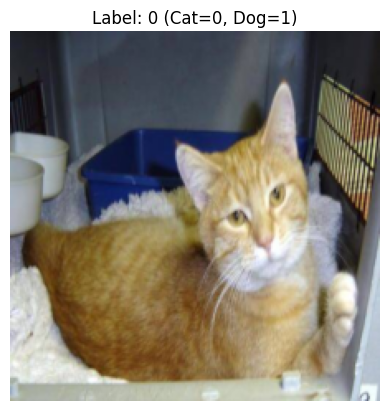

In [ ]:
image_tensor, label = dataset[250]
image_to_show = image_tensor.permute(1, 2, 0)

plt.imshow(image_to_show)
plt.title(f"Label: {label} (Cat=0, Dog=1)")
plt.axis('off')
plt.show()

In [ ]:
train_data = int(len(dataset) * 0.8)
test_data = len(dataset)-train_data

train_set, test_set = random_split(dataset, [train_data, test_data])

len(train_set), len(test_set)

(20000, 5000)

In [ ]:
train_dataloader = DataLoader(train_set, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
model.fc = nn.Linear(in_features=512, out_features=2)

In [ ]:
torch.device('cuda')
model = model.to('cuda')

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(3):

  train_total_loss = 0

  for img, label in train_dataloader:
    model.train()

    img, label = img.to('cuda'), label.to('cuda')

    optimizer.zero_grad()

    pred = model(img)
    loss = loss_fn(pred, label)
    train_total_loss += loss.item()

    loss.backward()
    optimizer.step()

  avg_train_loss = train_total_loss / len(train_dataloader)

  if epoch % 1 == 0:
    with torch.no_grad():

      model.eval()

      test_total_loss  = 0

      for img, label in test_dataloader:

        img, label = img.to('cuda'), label.to('cuda')

        pred = model(img)

        test_loss = loss_fn(pred, label)

        test_total_loss += test_loss.item()

    print(f'{epoch}: train loss = {loss}, test loss = {test_total_loss / len(test_dataloader)}')

0: train loss = 0.13550078868865967, test loss = 0.06191251799464226
1: train loss = 0.1331939399242401, test loss = 0.049851030111312866
2: train loss = 0.009737425483763218, test loss = 0.05160515382885933


In [ ]:
torch.save(model.state_dict(), 'Cats_vs_Dogs_Image_Classifier.pth')